# I. Preprocessing

Creation of the attributes and edges dataframes.
*These dataframes are already available so you can skip to part II.*

Name to gender dictionary from [World Gender Name Dictionary](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/MSEGSJ).

In [ ]:
import pandas as pd

with fs.open("s3://lab/wgnd.csv") as f:
    wgnd = pd.read_csv(f)

wgnd = wgnd.rename(columns={"Name":"name", "Gender" : "gender"})
wgnd = wgnd.drop_duplicates()
wgnd

,name,gender
0,baby,F
1,aisyah,F
2,anela,F
4,fiyinfoluwa,F
6,olioni,M
...,...,...
21831032,hyihwa,F
21831033,hyihwan,M
21831034,hyihun,M
21831037,hiyori,F


All paper publications extracted from the [DBLP xml dump](https://dblp.org/xml/).

In [3]:
with fs.open("s3://lab/art_net_dec.parquet") as f : 
    dfa = pd.read_parquet(f)
dfa

,title,journal,year,authors,dblp_uri,doi
0,Auswirkung der Digitalisierung auf die Systeml...,Elektrotech. Informationstechnik,2019,"[{'name': 'Kai Schlabitz', 'orcid': None}]",journals/ei/Schlabitz19,https://doi.org/10.1007/s00502-019-0687-y
1,EMF-Personenschutz: Neue Aspekte in der numeri...,Elektrotech. Informationstechnik,2020,"[{'name': 'Richard Überbacher', 'orcid': None}...",journals/ei/UberbacherC20,https://doi.org/10.1007/s00502-020-00791-z
2,Zur Genesis der Forschungsstelle für Integrier...,Elektrotech. Informationstechnik,2022,"[{'name': 'Herbert Mang', 'orcid': None}]",journals/ei/Mang22,https://doi.org/10.1007/s00502-022-01049-6
3,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,"[{'name': 'Sophie Knöttner', 'orcid': None}, {...",journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7
4,Application of multilateration for microphone ...,Elektrotech. Informationstechnik,2021,[],journals/ei/WimbergerR21,https://doi.org/10.1007/s00502-021-00885-2
...,...,...,...,...,...,...
3992218,"Derivability, Redundancy and Consistency of Re...","Research Report / RJ / IBM / San Jose, California",1969,"[{'name': 'E. F. Codd', 'orcid': None}]",persons/Codd69,None
3992219,Normalized Data Base Structure: A Brief Tutorial.,"Research Report / RJ / IBM / San Jose, California",1971,"[{'name': 'E. F. Codd', 'orcid': None}]",persons/Codd71b,None
3992220,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,"[{'name': 'Gayane Grigoryan', 'orcid': None}, ...",persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217
3992221,Common Subexpression Identification in General...,"Technical Rep. UKSC 0060, IBM United Kingdom S...",1974,"[{'name': 'Patrick A. V. Hall', 'orcid': None}]",persons/Hall74,None


Citation counts from the [DBLP SPARQL queries](https://sparql.dblp.org) based on the DBLP citation network.

In [ ]:
dfa["citations"] = pd.NA

for i in range(1,407):
    with fs.open(f"s3://lab/cite/dblp_{i}.csv") as f:
        temp = pd.read_csv(f)
    temp["dblp_uri"] = temp["dblp_uri"].str.replace(
        "https://dblp.org/rec/", "", regex=False
    )
    temp_map = (
        temp.drop_duplicates("dblp_uri")
          .set_index("dblp_uri")["citations"]
    )
    
    dfa["citations"] = (
        dfa["citations"]
        .combine_first(dfa["dblp_uri"].map(temp_map))
    )

/tmp/ipykernel_7130/4097367981.py:18: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  .combine_first(dfa["dblp_uri"].map(temp_map))


Preprocessing of the attributes dataframe.

In [5]:
dfa["authors"] = dfa["authors"].apply(lambda lst: [d["name"] for d in lst])
attr = dfa.explode("authors")
attr = attr.groupby("authors", as_index=False).agg({col: list for col in attr.columns if col != "authors"})

In [6]:
import re, string

attr["name"] = attr["authors"].str.split(" ").str[0].str.lower()
punct = re.escape(string.punctuation)
attr["name"] = attr["name"].str.replace(f'[{punct}]', '', regex=True)

In [17]:
attr = attr.merge(wgnd,how="left",on="name")
attr

,authors,title,journal,year,dblp_uri,doi,citations,name,gender
0,'Damola Adediji,"[Undermining competition, undermining markets?...",[Big Data Soc.],[2025],[journals/bigdatasociety/BirchA25],[None],[nan],damola,M
1,'Maseka Lesaoana,[A transportation branch and bound algorithm f...,"[Int. J. Syst. Assur. Eng. Manag., Oper. Res.]","[2015, 2001]","[journals/saem/MunapoLNK15, journals/ior/HallL...","[https://doi.org/10.1007/s13198-015-0343-9, ht...","[8.0, 70.0]",maseka,NaN
2,'Osaiasi Lolohea,[Visual literacy shown through a magnifying le...,[Interact. Technol. Smart Educ.],[2023],[journals/itse/ReddySCLT23],[https://doi.org/10.1108/ITSE-01-2022-0007],[2.0],osaiasi,NaN
3,(David) Jing Dai,[AutonomousGIS 2017 workshop report: the First...,[ACM SIGSPATIAL Special],[2017],[journals/sigspatial/GaoDHXC17],[https://doi.org/10.1145/3178392.3178407],[nan],david,M
4,(Max) Zong-Ming Cheng,[MicroSyn: A user friendly tool for detection ...,"[BMC Bioinform., BMC Bioinform.]","[2011, 2009]","[journals/bmcbi/CaiYTC11, journals/bmcbi/XuZHZ...","[https://www.wikidata.org/entity/Q28741346, ht...","[35.0, 186.0]",max,M
...,...,...,...,...,...,...,...,...,...
2700980,Þorsteinn Sæmundsson,[Inferring 2D Local Surface-Deformation Veloci...,[Remote. Sens.],[2022],[journals/remotesensing/DittrichHTS22],[None],[4.0],þorsteinn,NaN
2700981,Þröstur Pétursson,[Bone Mineral Density and Fracture Risk Assess...,[Comput. Math. Methods Medicine],[2015],[journals/cmmm/PeturssonEGMMHJ15],[https://www.wikidata.org/entity/Q36055821],[21.0],þröstur,NaN
2700982,Þórhildur Þorleiksdóttir,[Exquisitor: Interactive Learning at Large.],[CoRR],[2019],[journals/corr/abs-1904-08689],[None],[nan],þórhildur,NaN
2700983,Þórir Hrafn Harðarson,[Aligning Language Models for Icelandic Legal ...,[CoRR],[2025],[journals/corr/abs-2504-18180],[None],[nan],þórir,NaN


In [18]:
import numpy as np

attr["max_cite"] = attr["citations"].apply(np.max)

attr["mean_cite"] = attr["citations"].apply(np.mean)

In [22]:
attr.to_parquet("s3://lab/mem/art_attr.parquet")

Preprocessing of the edges dataframe.

In [28]:
from itertools import combinations

rows = []
for _, row in dfa.iterrows():
    for sender, receiver in combinations(row["authors"], 2):
        new_row = row.to_dict()
        new_row["sender"] = sender
        new_row["receiver"] = receiver
        rows.append(new_row)

edges_df = pd.DataFrame(rows).drop(columns=["authors"])

In [21]:
edges_df.to_parquet("s3://lab/mem/art_edges.parquet")

# II. Network modelisation

Creation of the network of co-authorship as a networkx object.
*You can also skip this part since we provide the main component of the graph in .pkl format.*

In [ ]:
import pandas as pd
with fs.open("s3://lab/mem/art_edges.parquet") as f : 
    edges = pd.read_parquet(f)

"""
For imports outside of s3 : 
with open("path/art_attr.parquet"", "rb") as f:
    attr = pd.read_parquet(f)
"""

edges

,title,journal,year,dblp_uri,doi,citations,sender,receiver,abrv,rank
0,EMF-Personenschutz: Neue Aspekte in der numeri...,Elektrotech. Informationstechnik,2020,journals/ei/UberbacherC20,https://doi.org/10.1007/s00502-020-00791-z,NaN,Richard Überbacher,Stefan Cecil,None,None
1,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Sophie Knöttner,Roman Geyer,None,None
2,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Sophie Knöttner,Christian Diendorfer,None,None
3,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Sophie Knöttner,Gerwin H. S. Drexler-Schmid,None,None
4,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Roman Geyer,Christian Diendorfer,None,None
...,...,...,...,...,...,...,...,...,...,...
17676648,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gronz,Rita Ley,None,None
17676649,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gronz,Andreas Rock,None,None
17676650,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gutjahr,Rita Ley,None,None
17676651,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gutjahr,Andreas Rock,None,None


In [ ]:
with fs.open("s3://lab/mem/art_attr.parquet") as f : 
    attr = pd.read_parquet(f)

"""
For imports outside of s3 : 
with open("path/art_attr.parquet"", "rb") as f:
    attr = pd.read_parquet(f)
"""

attr

,authors,title,journal,year,dblp_uri,doi,citations,name,gender,max_cite,mean_cite
0,'Damola Adediji,"[Undermining competition, undermining markets?...",[Big Data Soc.],[2025],[journals/bigdatasociety/BirchA25],[None],[nan],damola,M,NaN,NaN
1,'Maseka Lesaoana,[A transportation branch and bound algorithm f...,"[Int. J. Syst. Assur. Eng. Manag., Oper. Res.]","[2015, 2001]","[journals/saem/MunapoLNK15, journals/ior/HallL...","[https://doi.org/10.1007/s13198-015-0343-9, ht...","[8.0, 70.0]",maseka,None,70.0,39.0
2,'Osaiasi Lolohea,[Visual literacy shown through a magnifying le...,[Interact. Technol. Smart Educ.],[2023],[journals/itse/ReddySCLT23],[https://doi.org/10.1108/ITSE-01-2022-0007],[2.0],osaiasi,None,2.0,2.0
3,(David) Jing Dai,[AutonomousGIS 2017 workshop report: the First...,[ACM SIGSPATIAL Special],[2017],[journals/sigspatial/GaoDHXC17],[https://doi.org/10.1145/3178392.3178407],[nan],david,M,NaN,NaN
4,(Max) Zong-Ming Cheng,[MicroSyn: A user friendly tool for detection ...,"[BMC Bioinform., BMC Bioinform.]","[2011, 2009]","[journals/bmcbi/CaiYTC11, journals/bmcbi/XuZHZ...","[https://www.wikidata.org/entity/Q28741346, ht...","[35.0, 186.0]",max,M,186.0,110.5
...,...,...,...,...,...,...,...,...,...,...,...
2700980,Þorsteinn Sæmundsson,[Inferring 2D Local Surface-Deformation Veloci...,[Remote. Sens.],[2022],[journals/remotesensing/DittrichHTS22],[None],[4.0],þorsteinn,None,4.0,4.0
2700981,Þröstur Pétursson,[Bone Mineral Density and Fracture Risk Assess...,[Comput. Math. Methods Medicine],[2015],[journals/cmmm/PeturssonEGMMHJ15],[https://www.wikidata.org/entity/Q36055821],[21.0],þröstur,None,21.0,21.0
2700982,Þórhildur Þorleiksdóttir,[Exquisitor: Interactive Learning at Large.],[CoRR],[2019],[journals/corr/abs-1904-08689],[None],[nan],þórhildur,None,NaN,NaN
2700983,Þórir Hrafn Harðarson,[Aligning Language Models for Icelandic Legal ...,[CoRR],[2025],[journals/corr/abs-2504-18180],[None],[nan],þórir,None,NaN,NaN


In [31]:
%pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 84.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


We limit the analysis to publications after 1980 since DBLP has less precise records for ancient publications. We also exclude too recent papers.

In [4]:
edges = edges[(edges["year"].astype(int)>1980)&(edges["year"].astype(int)<2025)]

Converting the dataframes to nx object. Thanks to WGND, we have the gender of each node. We also have the mean of their papers citations among DBLP.

In [5]:
import networkx as nx

G = nx.Graph()

for _, row in edges.iterrows():
    G.add_edge(
        row["sender"], row["receiver"],
        year=row["year"],
        citations=row["citations"]
    )

for _, row in attr[["authors","gender","mean_cite"]].iterrows():
    if row["authors"] in G.nodes:
        G.nodes[row["authors"]].update(row.to_dict())

We make sure to remove self-loops to avoid further errors.

In [6]:
G.remove_edges_from(nx.selfloop_edges(G))

Since the network is very huge, we want to check if it can be decomposed.

In [7]:
graphs = list(nx.connected_components(G))

It happens that the graph only contain one huge interconnected component and a lot of very small components (only 12 have more than 50 nodes among millions of authors).

In [10]:
print("More than 20 nodes graphs sizes : ")
for i in graphs : 
    if len(i)>30 : 
        print(len(i))

print("\nTotal number of components : ", len(graphs))

More than 20 nodes graphs sizes : 
1744019
32
39
45
36
33
41
31
35
47
71
31

Total number of components :  80443


Thus, we stick to the main component of the graph. Doing so, we focus on the core of the computer science research field, its elite, which is precisely our research question.

In [11]:
core = G.subgraph(graphs[0]).copy()

An example of tie between two authors. 

In [13]:
u, v, d = list(core.edges(data=True))[0]
print(u, v, d)

Richard Überbacher Stefan Cecil {'year': '2020', 'citations': nan}


An example of node.

In [15]:
u, d = list(core.nodes(data=True))[0]
print(u, d)

Richard Überbacher {'authors': 'Richard Überbacher', 'gender': 'M', 'mean_cite': nan}


In [12]:
import pickle

# Save
with fs.open("s3://lab/mem/core_graph.pkl", "wb") as f:
    pickle.dump(core, f)

# III. Community detection and Rich-Club effect

In this section we identify communities with the Leiden algorythm (better at finding smallercommunities with more inner links than the Louvain one). We also measure the rich-club effect for each node of the graph.

In [ ]:
import pickle
with fs.open("s3://lab/mem/core_graph.pkl", "rb") as f:
    core = pickle.load(f)

"""
For imports outside of s3 : 
with open("path/core_graph.pkl", "rb") as f:
    core = pickle.load(f)
"""

In [15]:
%pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 22.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 93.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [leidenalg]/3 [leidenalg]
Note: you may need to restart the kernel to use updated packages.


We have to use igraph since Leiden algorythm is not implemented in netwrokx.

In [17]:
import igraph as ig

node_list = list(core.nodes())
node_idx = {n: i for i, n in enumerate(node_list)}

edges = [(node_idx[u], node_idx[v]) for u, v in core.edges()]

g_ig = ig.Graph(n=len(node_list), edges=edges, directed=False)
g_ig.vs["name"] = node_list
g_ig.vs["id"] = list(range(len(node_list)))

# add node attributes
for attr in ["gender", "mean_cite"]:
    g_ig.vs[attr] = [core.nodes[n].get(attr, None) for n in node_list]

We then run the leiden algorythm. We set the resolution parameter rather high to have smaller communities.
*It takes a couple minutes. We had to renounce to any temporal analysis precisely because of long computational times.*

In [18]:
import leidenalg

partition = leidenalg.find_partition(
    g_ig,
    leidenalg.RBConfigurationVertexPartition,
    resolution_parameter=5.0
)

We gather the nodes' informations.

In [19]:
import numpy as np

# Nodes
df_nodes = pd.DataFrame({
    "name":      g_ig.vs["name"],
    "community": partition.membership,
    "gender":    g_ig.vs["gender"],
    "mean_cite": g_ig.vs["mean_cite"],
    "degree":    g_ig.degree()
})

To better identify the "degree" elite, we add the rich-club coefficients, computed thanks to nx. Still because of computing time issues, we did not include the normalised version of the rich-club coefficients.

In [20]:
import networkx as nx

degree_dict = dict(core.degree())

rc = nx.rich_club_coefficient(core, normalized=False)

In [21]:
df_nodes["rc_coefficient"] = df_nodes["degree"].map(rc)
df_nodes

,name,community,gender,mean_cite,degree,rc_coefficient
0,Richard Überbacher,347,M,NaN,1,0.000008
1,Stefan Cecil,347,M,NaN,5,0.000026
2,Sophie Knöttner,72,F,NaN,3,0.000015
3,Roman Geyer,72,M,NaN,3,0.000015
4,Christian Diendorfer,72,M,NaN,3,0.000015
...,...,...,...,...,...,...
1744014,Matin Aghaei,123,M,NaN,3,0.000015
1744015,Hugo Hellebrand,105,M,105.0,2,0.000011
1744016,Oliver Gronz,105,M,25.0,4,0.000020
1744017,Oliver Gutjahr,105,M,21.0,4,0.000020


We then gather the communities informations, mostly means of their members attributes. We can see that there are a lot of communities, with very heterogrenous sizes.

In [22]:
# Communities
comm_stats = df_nodes.groupby("community").agg(
    size       = ("name", "count"),
    pct_female = ("gender", lambda x: (x == "F").mean()),
    mean_cite  = ("mean_cite", "mean"),
    mean_degree = ("degree", "mean"),
    mean_rc = ("rc_coefficient", "mean")
).reset_index()

comm_stats

,community,size,pct_female,mean_cite,mean_degree,mean_rc
0,0,32889,0.191219,18.651127,9.050290,0.000152
1,1,32761,0.123653,22.000472,6.483471,0.000079
2,2,28209,0.268319,35.114327,13.475309,0.000510
3,3,21224,0.338249,39.098834,6.470270,0.000101
4,4,20800,0.313702,14.258239,8.768894,0.000156
...,...,...,...,...,...,...
982,982,4,0.250000,13.166667,3.250000,0.000016
983,983,4,0.500000,11.750000,3.250000,0.000016
984,984,4,0.750000,NaN,3.250000,0.000016
985,985,4,0.500000,7.500000,3.250000,0.000016


We will now define what is an elite community, refering to the quantile distribution of their caracterstics. Thus, we can define a "citation" and a "degree" elite based on the mean number of citations and the mean rich-club coefficient within a community. These two elites do not intersect perfectly.

In [25]:

comm_stats["cite_elite"] = comm_stats["mean_cite"] >= comm_stats["mean_cite"].quantile(0.95)

comm_stats["rc_elite"] = comm_stats["mean_rc"] >= comm_stats["mean_rc"].quantile(0.95)

print(comm_stats[comm_stats["cite_elite"]].head())
print(comm_stats[comm_stats["rc_elite"]].head())

    community  size  pct_female   mean_cite  mean_degree   mean_rc  \
36         36  7883    0.322720   74.925698    37.400101  0.002280   
37         37  7594    0.323677   85.680938     9.875955  0.000262   
41         41  6971    0.398795   80.916003    14.472959  0.000479   
71         71  4930    0.271400  119.275604    13.937728  0.000392   
74         74  4838    0.401819  294.862247    25.596941  0.001050   

    cite_elite  rc_elite  
36        True      True  
37        True     False  
41        True     False  
71        True     False  
74        True     False  
    community   size  pct_female  mean_cite  mean_degree   mean_rc  \
21         21  11319    0.272020  21.289968    24.045322  0.001456   
30         30   8589    0.342182  44.792795    27.305041  0.001893   
36         36   7883    0.322720  74.925698    37.400101  0.002280   
59         59   5411    0.264646  18.049631    46.446313  0.004675   
65         65   5242    0.340519  22.507736    76.266692  0.011900 

To be able to analyse gendered patterns, we need first the proportion of women within our core network. We find around 36.9% which is higher than what can be found in the literature (20-30%). This can mainly be exaplained by the WGND, which did not manage to find 16% of authors.

In [26]:
len(df_nodes[df_nodes["gender"]=="F"])/len(df_nodes[~df_nodes["gender"].isna()])

0.36893553513359034

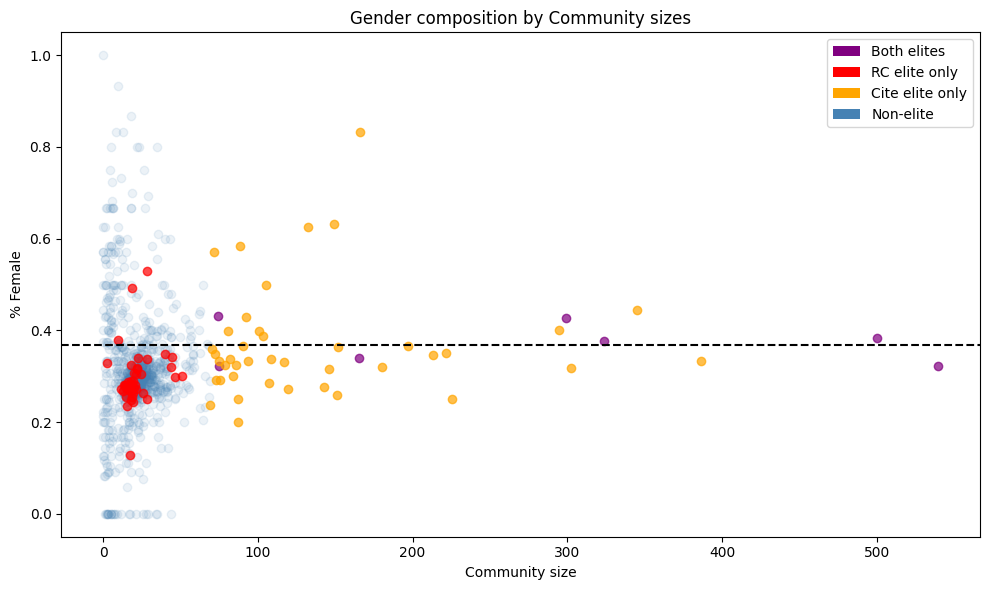

In [37]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 6))

# non-elite first (background)
ne = comm_stats[~comm_stats["rc_elite"] & ~comm_stats["cite_elite"]]
ax.scatter(ne["mean_cite"], ne["pct_female"], c="steelblue", alpha=0.1)

# elites on top
for color, mask in [
    ("purple", comm_stats["rc_elite"] & comm_stats["cite_elite"]),
    ("red",    comm_stats["rc_elite"] & ~comm_stats["cite_elite"]),
    ("orange", ~comm_stats["rc_elite"] & comm_stats["cite_elite"])
]:
    sub = comm_stats[mask]
    ax.scatter(sub["mean_cite"], sub["pct_female"], c=color, alpha=0.7)



# 36.8% reference line
ax.axhline(y=0.369, color="black", linestyle="--", label="37.1% baseline")

ax.set_xlabel("Community size")
ax.set_ylabel("% Female")
ax.set_title("Gender composition by Community sizes")

legend_elements = [
    Patch(facecolor="purple",   label="Both elites"),
    Patch(facecolor="red",      label="RC elite only"),
    Patch(facecolor="orange",   label="Cite elite only"),
    Patch(facecolor="steelblue",label="Non-elite")
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
import statsmodels.formula.api as smf

model = smf.ols("rc_coefficient ~ C(gender, Treatment('M')) + mean_cite + mean_cite:C(gender, Treatment('M'))", data=df_nodes).fit() #F ref bc alphabetic order
print(model.summary())

In [37]:
import statsmodels.formula.api as smf

quantiles = [0.25, 0.50, 0.75, 0.90, 0.93, 0.95, 0.97, 0.99]

for q in quantiles:
    model = smf.quantreg(
        "rc_coefficient ~ C(gender, Treatment('M')) + mean_cite + mean_cite:C(gender, Treatment('M'))",
        data=df_nodes
    ).fit(q=q)
    print(f"\nQuantile {q}")
    print(model.summary())


Quantile 0.25
                         QuantReg Regression Results                          
Dep. Variable:         rc_coefficient   Pseudo R-squared:            -0.007572
Model:                       QuantReg   Bandwidth:                   8.414e-07
Method:                 Least Squares   Sparsity:                    0.0001120
Date:                Sun, 26 Apr 2026   No. Observations:               628933
Time:                        14:57:32   Df Residuals:                   628929
                                        Df Model:                            3
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                 1.367e-05   8.83e-08    154.772      0.000    1.35e-05    1.38e-05
C(gender, Treatment('M'))[T.F]           -6.792e-07   1.42e-07     -4.777      0.000   -9.58e-07   -4.01e

In [38]:
gender_coefs = []
gender_ci_low = []
gender_ci_high = []
for q in quantiles:
    model = smf.quantreg(
        "rc_coefficient ~ C(gender, Treatment('M')) + mean_cite + mean_cite:C(gender, Treatment('M'))",
        data=df_nodes
    ).fit(q=q)
    
    coef = model.params["C(gender, Treatment('M'))[T.F]"]
    ci = model.conf_int().loc["C(gender, Treatment('M'))[T.F]"]
    gender_coefs.append(coef)
    gender_ci_low.append(ci[0])
    gender_ci_high.append(ci[1])

ols = smf.ols(
    "rc_coefficient ~ C(gender, Treatment('M')) + mean_cite + mean_cite:C(gender, Treatment('M'))",
    data=df_nodes
).fit()

ols_coef = ols.params["C(gender, Treatment('M'))[T.F]"]

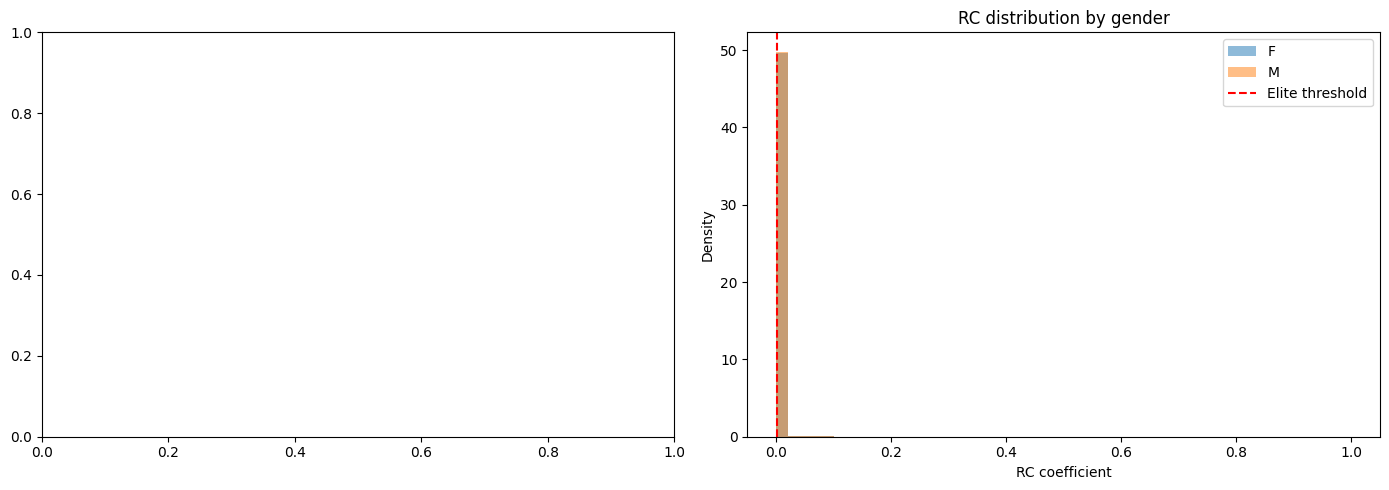

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: quantile coefficients ───────────────────────────────────────────────
ax.plot(quantiles, gender_coefs, color="steelblue", label="Quantile regression")
ax.fill_between(quantiles, gender_ci_low, gender_ci_high, alpha=0.2, color="steelblue")
ax.axhline(ols_coef, color="red", linestyle="--", label="OLS estimate")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(list(np.arange(0.1, 0.9, 0.1)) + list(np.arange(0.85, 1.0, 0.01)))
ax.tick_params(axis='x', rotation=45)
ax.set_xlim(0.85, 1.0)
ax.set_xlabel("Quantile")
ax.set_ylabel("Female coefficient")
ax.set_title("Gender gap across RC distribution")
ax.legend()

# ── Right: rc distribution by gender ─────────────────────────────────────────
for gender, group in df_nodes.groupby("gender"):
    axes[1].hist(group["rc_coefficient"], bins=50, alpha=0.5, label=gender, density=True)
axes[1].axvline(df_nodes["rc_coefficient"].quantile(0.95), 
                color="red", linestyle="--", label="Elite threshold")
axes[1].set_xlabel("RC coefficient")
axes[1].set_ylabel("Density")
axes[1].set_title("RC distribution by gender")
axes[1].legend()

plt.tight_layout()
plt.show()

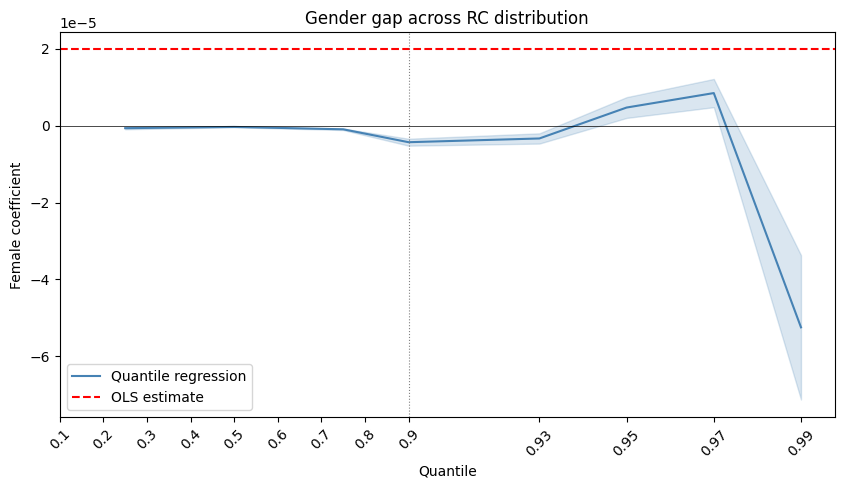

In [52]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 5))

# remap quantiles so 0.9-1.0 takes more visual space
def transform(x):
    return np.where(x <= 0.9, x * 0.5, 0.45 + (x - 0.9) * 5)

x_transformed = transform(quantiles)

ax.plot(x_transformed, gender_coefs, color="steelblue", label="Quantile regression")
ax.fill_between(x_transformed, gender_ci_low, gender_ci_high, alpha=0.2, color="steelblue")
ax.axhline(ols_coef, color="red", linestyle="--", label="OLS estimate")
ax.axhline(0, color="black", linewidth=0.5)

# set ticks back to original quantile values
tick_positions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.93, 0.95, 0.97, 0.99]
ax.set_xticks(transform(np.array(tick_positions)))
ax.set_xticklabels(tick_positions, rotation=45)
ax.axvline(transform(np.array([0.9])), color="grey", linestyle=":", linewidth=0.8)

ax.set_xlabel("Quantile")
ax.set_ylabel("Female coefficient")
ax.set_title("Gender gap across RC distribution")
ax.legend()

In [53]:
print((df_nodes["rc_coefficient"] >= df_nodes["rc_coefficient"].quantile(0.99)).sum())

18788


In [10]:
len(df_nodes[df_nodes["gender"]=="M"])/len(df_nodes[~df_nodes["gender"].isna()])

0.6291764986763667

In [ ]:
for g_year in graphs:
    g_year.vs["id"] = list(range(g_year.vcount()))
partitions, interslice = leidenalg.find_partition_temporal(
    graphs,
    leidenalg.RBConfigurationVertexPartition,
    interslice_weight=0.1,   # increase for more stable communities over time
    resolution_parameter=5.0
)

In [ ]:
results = []

for year, g_year, partition in zip(valid_years, graphs, partitions):
    
    # add community membership to graph
    g_year.vs["community"] = partition.membership
    
    # build a dataframe of nodes for this year
    df_year = pd.DataFrame({
        "name":      g_year.vs["name"],
        "community": g_year.vs["community"],
        "gender":    g_year.vs["gender"],
        "mean_cite": g_year.vs["mean_cite"],
        "degree":    [g_year.degree(i) for i in range(n_nodes)],
        "year":      year
    })
    
    # community-level stats
    comm_stats = df_year.groupby("community").agg(
        size        = ("name", "count"),
        pct_female  = ("gender", lambda x: (x == "F").mean()),
        mean_cite   = ("mean_cite", "mean"),
        mean_degree = ("degree", "mean")
    ).reset_index()
    
    comm_stats["year"] = year
    
    # flag elite communities (top 5% by mean degree)
    threshold = comm_stats["mean_degree"].quantile(0.95)
    comm_stats["is_elite"] = comm_stats["mean_degree"] >= threshold
    
    results.append(comm_stats)

df_results = pd.concat(results, ignore_index=True)


elite_gender = (
    df_results[df_results["is_elite"]]
    .groupby("year")["pct_female"]
    .mean()
    .reset_index()
)

print(elite_gender)


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# % female in elite communities over time
axes[0].plot(elite_gender["year"], elite_gender["pct_female"])
axes[0].set_title("% Female in Elite Communities over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("% Female")

# overall % female vs elite % female
overall_gender = (
    df_results.groupby("year")["pct_female"].mean().reset_index()
)
axes[1].plot(overall_gender["year"], overall_gender["pct_female"], label="Overall")
axes[1].plot(elite_gender["year"], elite_gender["pct_female"], label="Elite")
axes[1].set_title("Overall vs Elite % Female")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    "pct_female ~ is_elite + mean_cite + year", 
    data=df_results
).fit()
print(model.summary())

In [ ]:
graphs = []
for year in range(2000, 2024):
    edges = df[df["year"] == year][["source", "target"]].values.tolist()
    g_year = ig.Graph(n=n_nodes, edges=edges)
    graphs.append(g_year)

partition, interslice = leidenalg.find_partition_temporal(
    graphs,
    leidenalg.RBConfigurationVertexPartition,
    interslice_weight=0.1,
    resolution_parameter=2.0
)

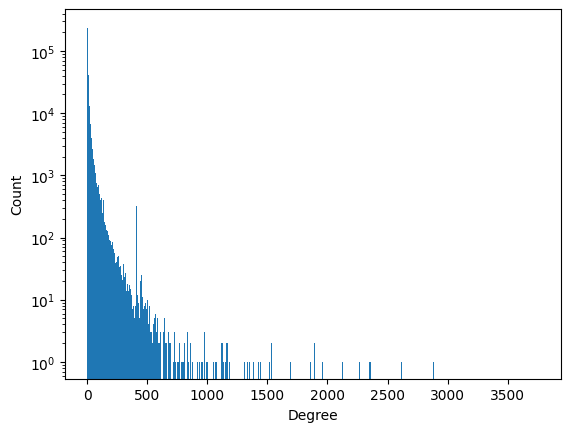

In [48]:
import matplotlib.pyplot as plt
import numpy as np
degree_sequence = sorted((d for n, d in core.degree()), reverse=True)
plt.hist(degree_sequence, bins=range(min(degree_sequence), max(degree_sequence) + 2))
plt.yscale("log")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

In [43]:
nx.average_node_connectivity(core)

KeyboardInterrupt: 

In [ ]:
nx.flow_hierarchy(core)